# 02 — Feature Engineering
**PIX Fraud Intelligence | IBM Portfolio Project**

**Goals:**
- Load the sampled PIX Fraud BR dataset
- Encode categorical features (`tipo_transacao`, `dia_semana`)
- Select features for modeling (drop IDs, datetime, redundant columns)
- Handle class imbalance with SMOTE
- Produce train/test splits ready for DB2 ingestion and AutoAI

In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../config', exist_ok=True)

## 1. Load Sampled Data

In [2]:
df = pd.read_parquet('../data/raw/transactions_sampled.parquet')
print(f"Shape: {df.shape} | Fraud rate: {df['fraude'].mean():.4%}")
df.head(3)

Shape: (100000, 17) | Fraud rate: 13.7350%


,id_pagador,id_recebedor,tipo_transacao,valor_brl,saldo_anterior_pagador,saldo_posterior_pagador,saldo_anterior_recebedor,saldo_posterior_recebedor,datetime_brasilia,hora_dia,dia_semana,dia_util,horario_noturno,acima_limite_noturno,razao_saldo_residual,proporcao_valor_recebedor,fraude
0,***.473.944-**,***.479.606-**,pix_copia_e_cola,275046.12,1519325.03,1244278.91,62024.32,337070.44,2024-01-19 17:00:00,19,quarta-feira,True,False,False,0.818968,0.815990,0
1,***.607.842-**,***.374.222-**,chave_pix,188339.61,906202.46,717862.85,7874.27,196213.88,2024-01-12 19:00:00,19,quarta-feira,True,False,False,0.792166,0.959869,0
2,***.892.940-**,***.229.292-**,pix_copia_e_cola,2423286.20,11150322.81,8727036.61,107409.98,2530696.18,2024-01-16 15:00:00,15,terã§a-feira,True,False,False,0.782671,0.957557,0


## 2. Encode Categorical Features

In [3]:
# Split primeiro para evitar leakage: encoders são fit apenas no treino
X_raw = df.drop(columns=['fraude'])
y     = df['fraude']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

le_tipo = LabelEncoder()
le_dia  = LabelEncoder()

X_train_raw = X_train_raw.copy()
X_test_raw  = X_test_raw.copy()

X_train_raw['tipo_transacao_enc'] = le_tipo.fit_transform(X_train_raw['tipo_transacao'])
X_test_raw['tipo_transacao_enc']  = le_tipo.transform(X_test_raw['tipo_transacao'])

X_train_raw['dia_semana_enc'] = le_dia.fit_transform(X_train_raw['dia_semana'])
X_test_raw['dia_semana_enc']  = le_dia.transform(X_test_raw['dia_semana'])

# Persistir encoders para uso no deploy
joblib.dump(le_tipo, '../config/le_tipo.pkl')
joblib.dump(le_dia,  '../config/le_dia.pkl')
print('Encoders salvos em config/')
print('tipo_transacao:', dict(zip(le_tipo.classes_, le_tipo.transform(le_tipo.classes_))))
print('dia_semana (3 primeiros):', dict(list(zip(le_dia.classes_[:3], le_dia.transform(le_dia.classes_[:3])))))

Encoders salvos em config/
tipo_transacao: {'chave_pix': np.int64(0), 'dados_bancarios': np.int64(1), 'pix_copia_e_cola': np.int64(2)}
dia_semana (3 primeiros): {'domingo': np.int64(0), 'quarta-feira': np.int64(1), 'quinta-feira': np.int64(2)}


## 3. Feature Selection

In [4]:
# Colunas removidas:
#   - IDs e datetime: não preditivos
#   - tipo_transacao / dia_semana: substituídos pelos encoded
#   - saldo_posterior_pagador: derivado de saldo_anterior_pagador - valor_brl (multicolinear)
#   - saldo_posterior_recebedor: derivado de saldo_anterior_recebedor + valor_brl (multicolinear)
DROP_COLS = [
    'id_pagador', 'id_recebedor', 'datetime_brasilia',
    'tipo_transacao', 'dia_semana',
    'saldo_posterior_pagador',
    'saldo_posterior_recebedor',
]

FEATURES = [c for c in X_train_raw.columns if c not in DROP_COLS]
TARGET   = 'fraude'

print(f"Features selecionadas ({len(FEATURES)}):")
for f in FEATURES:
    print(f"  {f}")

Features selecionadas (11):
  valor_brl
  saldo_anterior_pagador
  saldo_anterior_recebedor
  hora_dia
  dia_util
  horario_noturno
  acima_limite_noturno
  razao_saldo_residual
  proporcao_valor_recebedor
  tipo_transacao_enc
  dia_semana_enc


## 4. Train / Test Split

In [5]:
X_train = X_train_raw[FEATURES].astype(float)
X_test  = X_test_raw[FEATURES].astype(float)

print(f"Train: {X_train.shape} | Fraud rate: {y_train.mean():.4%}")
print(f"Test:  {X_test.shape}  | Fraud rate: {y_test.mean():.4%}")

Train: (80000, 11) | Fraud rate: 13.7350%
Test:  (20000, 11)  | Fraud rate: 13.7350%


## 5. SMOTE — Balancing the Training Set

Before SMOTE: {0: 69012, 1: 10988}
After  SMOTE: {0: 69012, 1: 34506}


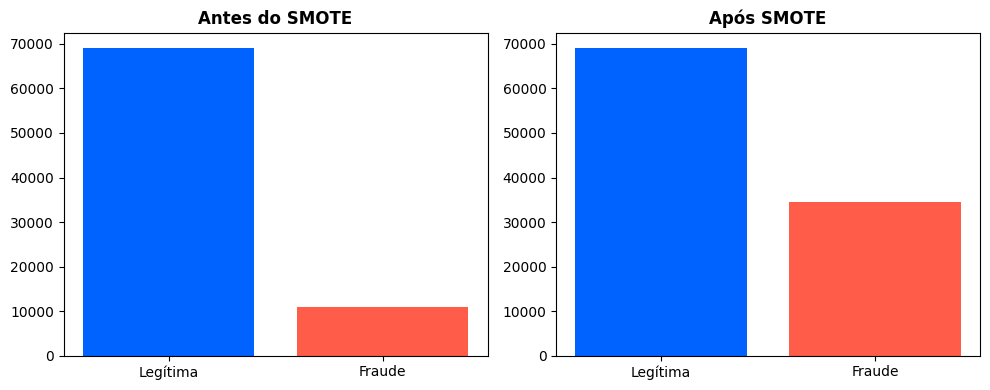

In [6]:
# SMOTE oversamples the minority (fraud) class for the local baseline.
# The 100k sample is already ~14% fraud (notebook 01 weights fraud heavily),
# so we target a 0.5 minority:majority ratio. This file is a local baseline only —
# notebooks 03-05 use the non-SMOTE transactions_features.parquet.
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After  SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(
    axes,
    [y_train.value_counts(), pd.Series(y_train_res).value_counts()],
    ['Antes do SMOTE', 'Após SMOTE']
):
    ax.bar(['Legítima', 'Fraude'], counts.values, color=['#0062ff', '#ff5c49'])
    ax.set_title(title, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Save Processed Data

In [7]:
# Full dataset (sem SMOTE) → DB2 ingestion no notebook 03
train_df = X_train.copy(); train_df['fraude'] = y_train.values; train_df['split'] = 'train'
test_df  = X_test.copy();  test_df['fraude']  = y_test.values;  test_df['split']  = 'test'
full_df  = pd.concat([train_df, test_df]).reset_index(drop=True)
full_df.to_parquet('../data/processed/transactions_features.parquet', index=False)

# SMOTE'd training set → baseline local (não usado pelo AutoAI)
X_res_df = pd.DataFrame(X_train_res, columns=X_train.columns)
X_res_df['fraude'] = y_train_res
X_res_df.to_parquet('../data/processed/train_resampled.parquet', index=False)

print(f"transactions_features.parquet : {len(full_df):,} rows, {full_df.shape[1]} cols")
print(f"train_resampled.parquet       : {len(X_res_df):,} rows  (baseline local)")
print(f"\nFeatures para modelagem ({len(FEATURES)}): {FEATURES}")

transactions_features.parquet : 100,000 rows, 13 cols
train_resampled.parquet       : 103,518 rows  (baseline local)

Features para modelagem (11): ['valor_brl', 'saldo_anterior_pagador', 'saldo_anterior_recebedor', 'hora_dia', 'dia_util', 'horario_noturno', 'acima_limite_noturno', 'razao_saldo_residual', 'proporcao_valor_recebedor', 'tipo_transacao_enc', 'dia_semana_enc']
